# 00_12 — Comparación numérica MATLAB ↔ Python (PSBP-FD v2)

**Objetivo:** validar que la implementación Python (`PSBPSampler` + `PSBPPredictor` orquestados por `PSBP_FD_v2`) reproduce, en distribución posterior, los resultados del código MATLAB original de Chung & Dunson (2009) sobre los datos `BHPin_1.txt` / `BHPout_1.txt`.

Aqui solo ejecutremos los codigos de python nada mas.

## 1. Imports, rutas y carga del `.mat`

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, time
from scipy.io import loadmat
from scipy.stats import norm

# ── Raíz del proyecto ──────────────────────────────────────────────────
def get_project_root(marker: str = "README.md") -> Path:
    current = Path(os.getcwd()).resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    return current

PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

# ── Rutas ──────────────────────────────────────────────────────────────
PATHS = {
    "raw":      PROJECT_ROOT / "data" / "simulaciones" / "raw",
    "mat":      PROJECT_ROOT / "data" / "simulaciones" / "raw",  # poner BHP_1.mat aquí
    "reports":  PROJECT_ROOT / "reports" / "simulaciones" / "matlab_vs_python_2",
}
PATHS["reports"].mkdir(parents=True, exist_ok=True)

BASEFNAME = "BHP"
TT        = 1
SEED      = 421321  # arbitraria; las trazas individuales no son comparables igual

print(f"\nRutas:")
for k, v in PATHS.items():
    print(f"  {k:8s} → {v}")

PROJECT_ROOT: C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd

Rutas:
  raw      → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\raw
  mat      → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\raw
  reports  → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\reports\simulaciones\matlab_vs_python_2


## 2. Carga directa de `BHPin_1.txt` / `BHPout_1.txt` y estandarización

In [25]:
# ── Carga de los .txt crudos ───────────────────────────────────────────
path_in  = PATHS["raw"] / f"{BASEFNAME}in_{TT}.txt"
path_out = PATHS["raw"] / f"{BASEFNAME}out_{TT}.txt"

dt_train = np.loadtxt(path_in)    # (n,  1+p) — col 0 es y
dt_test  = np.loadtxt(path_out)   # (n2, 1+p)

n,  p1 = dt_train.shape
n2, _  = dt_test.shape
p      = p1 - 1
print(f"Train: n  = {n},  p = {p}")
print(f"Test:  n2 = {n2}, p = {p}")

# ── Estandarización con MATLAB ddof=0 ──────────────────────────────────
#  IMPORTANTE: usar np.std(..., ddof=0) — el default de pandas es ddof=1
dt_mean = dt_train.mean(axis=0)
dt_std  = dt_train.std(axis=0, ddof=0)

dt_train_std = (dt_train - dt_mean) / dt_std
dt_test_std  = (dt_test  - dt_mean) / dt_std

# ── Construir DataFrame de entrenamiento ──────────────────────────────
df_train = pd.DataFrame(
    dt_train_std,
    columns=["y"] + [f"x{j+1}" for j in range(p)],
)
df_test = pd.DataFrame(
    dt_test_std,
    columns=["y"] + [f"x{j+1}" for j in range(p)],
)
print(f"\ndf_train shape: {df_train.shape}")
print(df_train.head(3))

Train: n  = 249,  p = 13
Test:  n2 = 125, p = 13

df_train shape: (249, 14)
          y        x1        x2        x3        x4        x5        x6  \
0 -0.894565 -0.557821  0.695499 -0.432297 -0.295527 -0.741107 -1.009233   
1  0.414807 -0.559309  0.620056 -1.040311 -0.295527 -0.415497  0.675903   
2  2.443744 -0.581453  0.129677 -0.860101 -0.295527 -0.693364  2.107457   

         x7        x8        x9       x10       x11       x12       x13  
0 -1.242294  1.052115 -2.121417 -0.154098 -0.384493  0.338922  0.240811  
1  0.289954 -0.558429  1.576829 -1.178978  0.290357  0.408415 -0.553579  
2  0.077853  0.145776  0.344080 -1.253969 -1.284292  0.177013 -1.164773  


## 3. Ejecutar `PSBP_FD_v2` con la misma configuración MCMC del `.m`

| Hiperparámetro | Valor MATLAB | Valor Python |
|---|---|---|
| nsim | 2000 | 2000 |
| burn | 200 | 200 |
| N (trunc.) | 20 | 20 |
| M (grilla) | 50 | 50 |
| atau, btau | 0.5, 0.5 | 0.5, 0.5 |
| ag, bg | 0.5, 0.5 | 0.5, 0.5 |
| apij, bpij | 1, 5 | 1, 5 |
| mumu, taumu | 0, 1 | 0, 1 |
| mupsij, taupsij | 0, 1 | 0, 1 |
| pwj | 0.5 | 0.5 |

In [26]:
from model_psbp_fd.models.psbp_fd_v2.psbp_fd_v2 import PSBP_FD_v2

MCMC_CFG = {"nsim": 2000, "burn": 200, "N": 20, "M": 50}
HP = {
    "atau":  0.5, "btau":  0.5,
    "ag":    0.5, "bg":    0.5,
    "apij":  1.0, "bpij":  5.0,
    "mumu":  0.0, "taumu": 1.0,
    "mupsij":  0.0, "taupsij": 1.0,
    "pwj":   0.5,
}

print("Ajustando PSBP_FD_v2 ...")
t0 = time.perf_counter()
model = PSBP_FD_v2(
    mcmc_cfg=MCMC_CFG, hp=HP,
    seed=SEED, verbose_every=200,
).fit(df_train)
elapsed = time.perf_counter() - t0
print(f"\nFit completado en {elapsed:.1f}s ({elapsed/60:.2f} min).")

traces = model.traces
print(f"\nClaves de trazas Python: {sorted(traces.keys())}")

Ajustando PSBP_FD_v2 ...
  iter 200/2000
  iter 400/2000
  iter 600/2000
  iter 800/2000
  iter 1000/2000
  iter 1200/2000
  iter 1400/2000
  iter 1600/2000
  iter 1800/2000
  iter 2000/2000

Fit completado en 9466.6s (157.78 min).

Claves de trazas Python: ['Gammajhout', 'N1out', 'Nout', 'alphahout', 'beta0hout', 'betajhout', 'gammajhout', 'inEout', 'muout', 'osumout', 'pijout', 'psijhout', 'tauhout', 'wjout']


## 4. RMSE

In [27]:
# ── RMSE Python en escala estandarizada ────────────────────────────────────────
rmse_py_in_std  = model.rmse(df_train)
rmse_py_out_std = model.rmse(df_test)

print(f"RMSE in-sample  (estandarizado): {rmse_py_in_std:.6f}")
print(f"RMSE out-of-sample (estandarizado): {rmse_py_out_std:.6f}")

RMSE in-sample  (estandarizado): 0.428630
RMSE out-of-sample (estandarizado): 0.395942


## 5. Probabilidades de inclusión por variable



P(γ_j = 1 | data) por variable:
  P(γ=1 | x1    ) = 0.0367
  P(γ=1 | x2    ) = 0.0272
  P(γ=1 | x3    ) = 0.0422
  P(γ=1 | x4    ) = 0.0372
  P(γ=1 | x5    ) = 0.0328
  P(γ=1 | x6    ) = 1.0000  *
  P(γ=1 | x7    ) = 0.9994  *
  P(γ=1 | x8    ) = 0.1950
  P(γ=1 | x9    ) = 0.0367
  P(γ=1 | x10   ) = 0.0506
  P(γ=1 | x11   ) = 1.0000  *
  P(γ=1 | x12   ) = 0.2856
  P(γ=1 | x13   ) = 0.0500


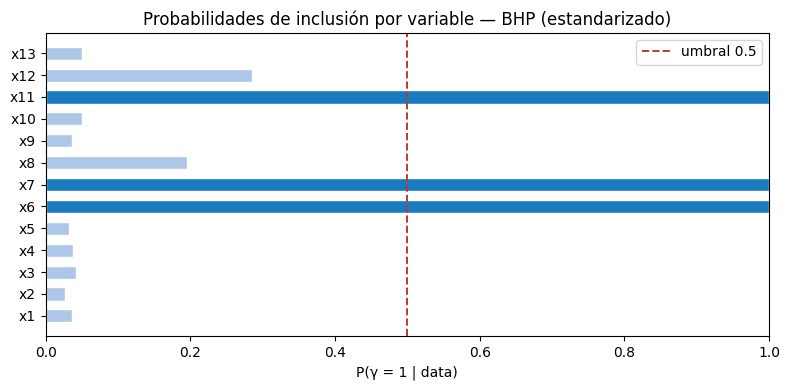

In [28]:
# ── Probabilidades de inclusión por variable ────────────────────────────────────
incl = model.inclusion_probs(as_series=True)

print("P(γ_j = 1 | data) por variable:")
for name, val in incl.items():
    print(f"  P(γ=1 | {name:<6}) = {val:.4f}{'  *' if val > 0.5 else ''}")

# ── Gráfico de barras ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors  = ["#1a7abf" if v > 0.5 else "#aec7e8" for v in incl.values]
ax.barh(incl.index, incl.values, color=colors, edgecolor="white", height=0.6)
ax.axvline(0.5, color="#c0392b", lw=1.4, ls="--", label="umbral 0.5")
ax.set_xlabel("P(γ = 1 | data)")
ax.set_title("Probabilidades de inclusión por variable — BHP (estandarizado)")
ax.set_xlim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(PATHS["reports"] / "01_inclusion_probs.png", dpi=150)
plt.show()

## 6. Scaterplot Real vs Predicho

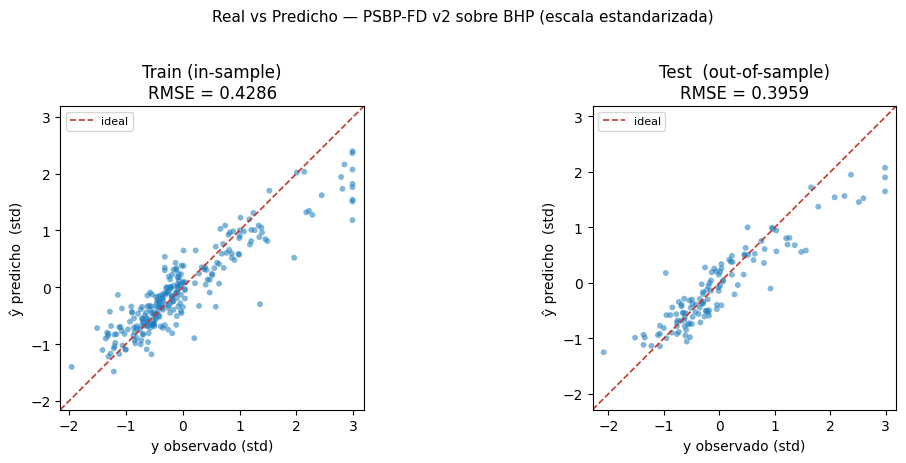

In [29]:
# ── Predicciones en escala estandarizada ────────────────────────────────────────
y_hat_train = model.predict(df_train)
y_hat_test  = model.predict(df_test)
y_obs_train = df_train.iloc[:, 0].to_numpy()
y_obs_test  = df_test.iloc[:, 0].to_numpy()

# ── Scatterplot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, y_obs, y_hat, label, rmse_val in [
    (axes[0], y_obs_train, y_hat_train, "Train (in-sample)",     rmse_py_in_std),
    (axes[1], y_obs_test,  y_hat_test,  "Test  (out-of-sample)", rmse_py_out_std),
]:
    lims = [
        min(y_obs.min(), y_hat.min()) - 0.2,
        max(y_obs.max(), y_hat.max()) + 0.2,
    ]
    ax.scatter(y_obs, y_hat, s=18, alpha=0.55, edgecolors="none", color="#1a7abf")
    ax.plot(lims, lims, "--", color="#c0392b", lw=1.2, label="ideal")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("y observado (std)")
    ax.set_ylabel("ŷ predicho  (std)")
    ax.set_title(f"{label}\nRMSE = {rmse_val:.4f}")
    ax.legend(fontsize=8)
    ax.set_aspect("equal")

fig.suptitle("Real vs Predicho — PSBP-FD v2 sobre BHP (escala estandarizada)",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(PATHS["reports"] / "02_scatter_real_vs_predicho.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 7. Distribuciones marginales posteriores de hiperparámetros 
- Analizar trazas 
- Ver ACF 
- Ver distribucion 

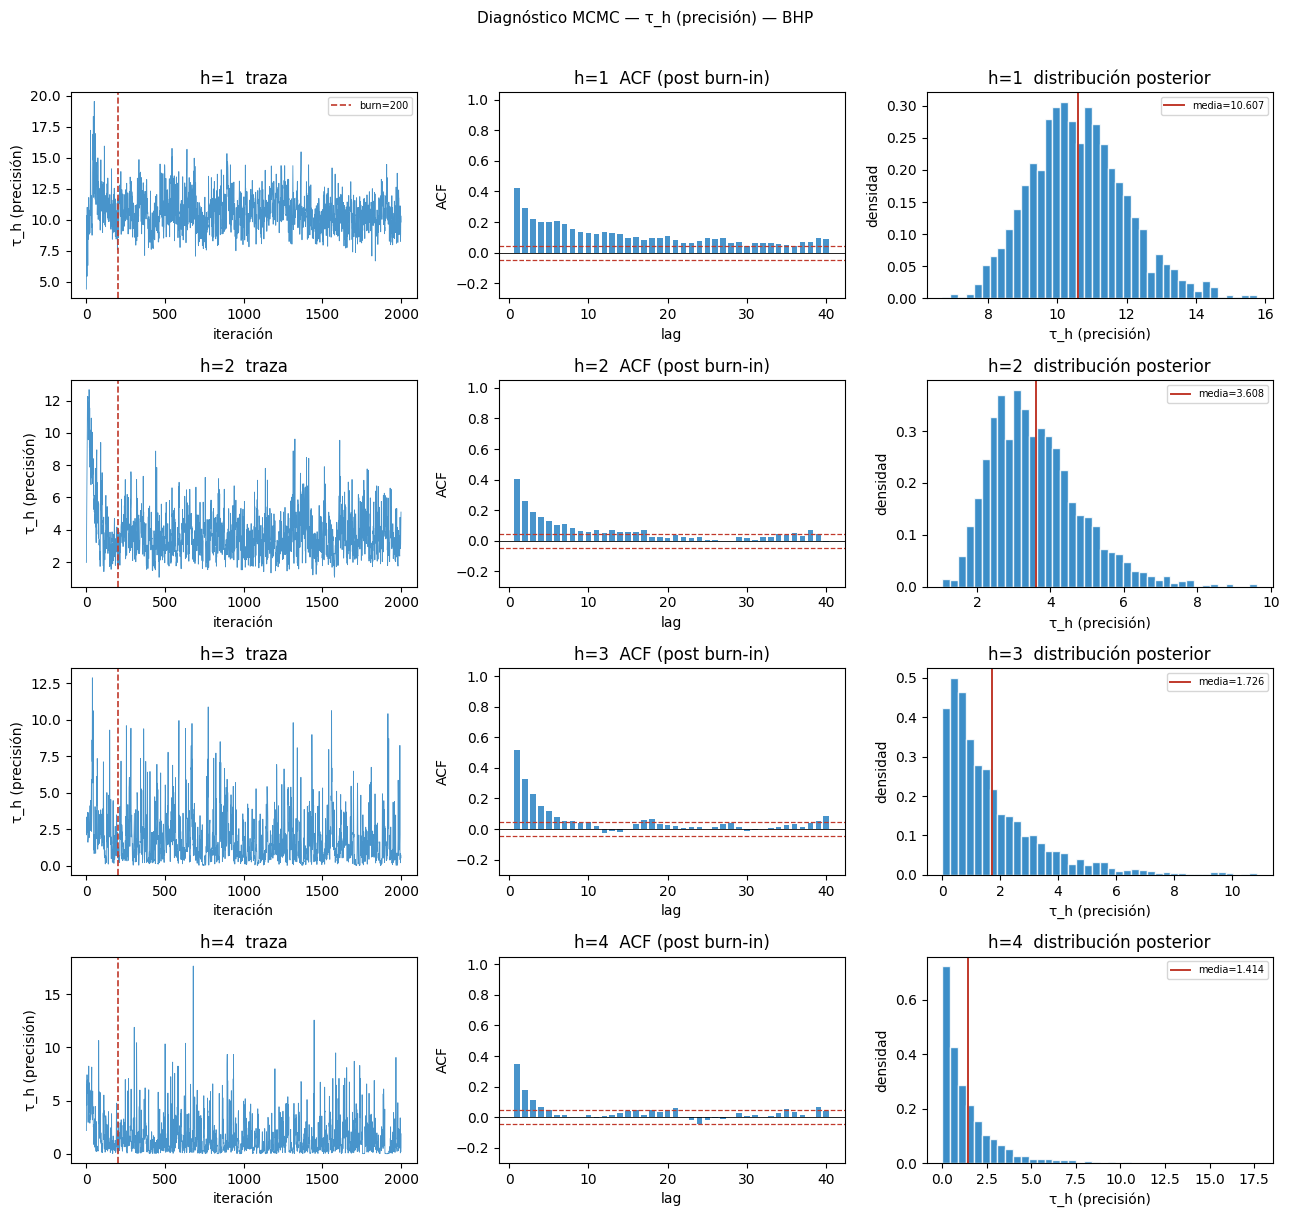

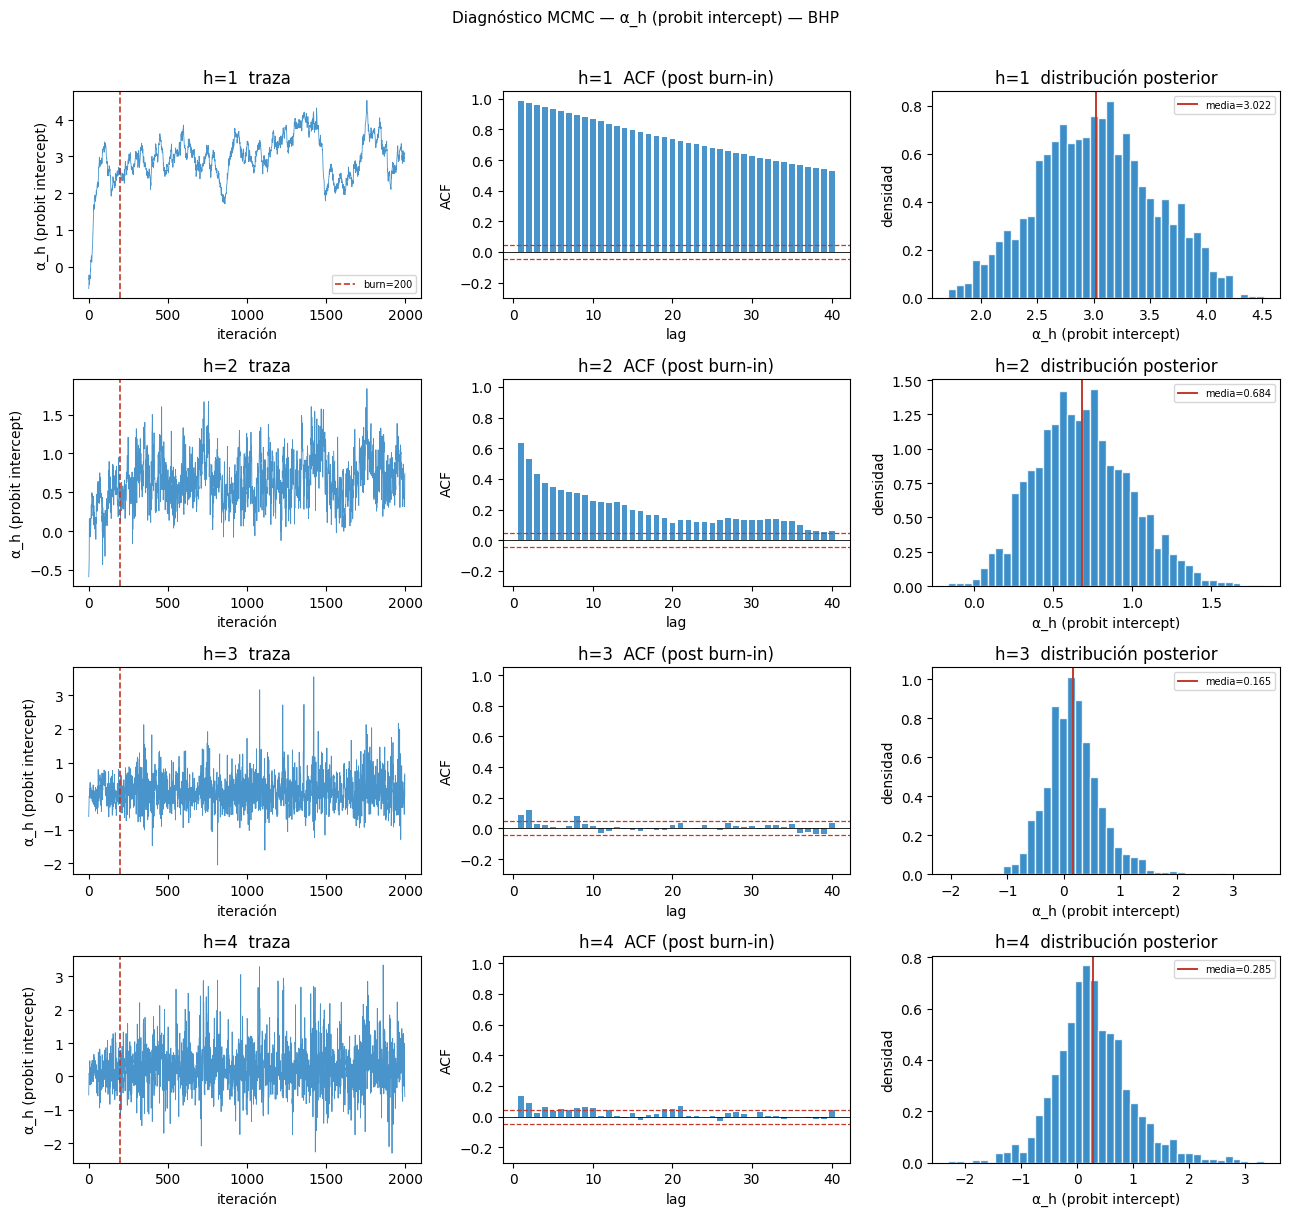

In [30]:
# ── Seleccionar parámetros a analizar ───────────────────────────────────────────
# tauhout  : (nsim, N)   — precisiones de cada componente
# alphahout: (nsim, N-1) — interceptos del probit stick-breaking
BURN  = int(MCMC_CFG["burn"])
nsim  = int(MCMC_CFG["nsim"])
N     = int(MCMC_CFG["N"])

tau_trace   = traces["tauhout"]    # (nsim, N)
alpha_trace = traces["alphahout"]  # (nsim, N-1)

# ── Índices de componentes a mostrar (primeros 4) ───────────────────────────────
n_show  = min(4, N)
iters   = np.arange(nsim)

for param_name, trace_full, n_comp_show in [
    ("τ_h (precisión)",      tau_trace,   n_show),
    ("α_h (probit intercept)", alpha_trace, n_show),
]:
    fig, axes = plt.subplots(n_comp_show, 3,
                             figsize=(13, 3.0 * n_comp_show))
    axes = np.array(axes).reshape(n_comp_show, 3)

    for h in range(n_comp_show):
        chain_full = trace_full[:, h]        # (nsim,)
        chain_post = chain_full[BURN:]        # post burn-in

        # — traza completa con línea de burn-in —
        ax = axes[h, 0]
        ax.plot(iters, chain_full, lw=0.6, color="#1a7abf", alpha=0.8)
        ax.axvline(BURN, color="#c0392b", lw=1.2, ls="--", label=f"burn={BURN}")
        ax.set_title(f"h={h+1}  traza")
        ax.set_xlabel("iteración"); ax.set_ylabel(param_name)
        if h == 0: ax.legend(fontsize=7)

        # — ACF post-burn-in —
        ax = axes[h, 1]
        n_lags_acf = 40
        acf_vals   = np.array([
            np.corrcoef(chain_post[:-lag], chain_post[lag:])[0, 1]
            for lag in range(1, n_lags_acf + 1)
        ])
        ci = 1.96 / np.sqrt(len(chain_post))
        ax.bar(np.arange(1, n_lags_acf + 1), acf_vals,
               color="#1a7abf", width=0.7, alpha=0.8)
        ax.axhline( ci, color="#c0392b", lw=0.9, ls="--")
        ax.axhline(-ci, color="#c0392b", lw=0.9, ls="--")
        ax.axhline(0,   color="black",   lw=0.6)
        ax.set_title(f"h={h+1}  ACF (post burn-in)")
        ax.set_xlabel("lag"); ax.set_ylabel("ACF")
        ax.set_ylim(-0.3, 1.05)

        # — distribución posterior —
        ax = axes[h, 2]
        ax.hist(chain_post, bins=40, color="#1a7abf", edgecolor="white",
                alpha=0.85, density=True)
        ax.axvline(chain_post.mean(), color="#c0392b", lw=1.4, ls="-",
                   label=f"media={chain_post.mean():.3f}")
        ax.set_title(f"h={h+1}  distribución posterior")
        ax.set_xlabel(param_name); ax.set_ylabel("densidad")
        ax.legend(fontsize=7)

    fig.suptitle(f"Diagnóstico MCMC — {param_name} — BHP",
                 fontsize=11, y=1.01)
    fig.tight_layout()
    safe_name = param_name.split(" ")[0].replace("τ","tau").replace("α","alpha")
    fig.savefig(PATHS["reports"] / f"03_diagnostico_{safe_name}.png",
                dpi=150, bbox_inches="tight")
    plt.show()